In [16]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


from matplotlib.colors import LinearSegmentedColormap

ruta_raiz = 'C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/'
# ruta_raiz = '/Users/antonio_lopez_torres/Documents/GitHub/RRAM_Simulation/' # Ruta en el mac

sys.path.append(ruta_raiz) # añade la ruta especificada en la variable ruta_raiz al sistema de búsqueda de módulos de Python. Esto permite que Python pueda importar módulos o paquetes que se encuentren en esa ruta, incluso si no están en el directorio actual o en las rutas estándar.
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Rutas

In [17]:
num_simulation = 9
paso_voltaje = 0.00014
paso_temporal = 0.001

# Rutas de guardado de figuras
figures_path = 'C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Figuras_def/'

# Rutas datos
simulation_path = os.path.join('Results', f'simulation_{num_simulation}/')
set_simulation_path = os.path.join('Results', f'simulation_{num_simulation}/set/')
reset_simulation_path = os.path.join('Results', f'simulation_{num_simulation}/reset/')

# Rutas a los estados de configuración y oxígeno
config_ps = set_simulation_path + f'Configurations_pp_set_{num_simulation}.pkl'
config_ss = set_simulation_path + f'Configurations_sp_set_{num_simulation}.pkl'
config_pr = reset_simulation_path + f'Configurations_pp_reset_{num_simulation}.pkl'
config_sr = reset_simulation_path + f'Configurations_sp_reset_{num_simulation}.pkl'

oxygen_pr = reset_simulation_path + f'Oxygen_pp_reset_{num_simulation}.pkl'
oxygen_sr = reset_simulation_path + f'Oxygen_sp_reset_{num_simulation}.pkl'

# Rutas a los dataframes
data_path_pp_set = set_simulation_path + f'resultados_pp_set_{num_simulation}.csv'
data_path_sp_set = set_simulation_path + f'resultados_sp_set_{num_simulation}.csv'
data_path_pp_reset = reset_simulation_path + f'resultados_pp_reset_{num_simulation}.csv'
data_path_sp_reset = reset_simulation_path + f'resultados_sp_reset_{num_simulation}.csv'

### Configuraciones de estilo para todos los plots

In [18]:
# region Configuración del plot
def config_ax(ax):
    # ax.grid(which='major', color='#DDDDDD', linewidth=0.8, zorder=-1)
    # ax.grid(which='minor', color='#DEDEDE', linestyle=':', linewidth=0.5, zorder=-1)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)


def setup_plt(plt, latex=True, scaling=1):
    plt.rcParams.update(
        {
            "pgf.texsystem": "pdflatex",
            "text.usetex": latex,
            "font.family": "fourier",
            "text.latex.preamble": "\n".join([
                r"\usepackage[utf8]{inputenc}",
                r"\usepackage[T1]{fontenc}",
                r"\usepackage{siunitx}",
            ])
        }
    )

    SMALL_SIZE = 8 * scaling
    MEDIUM_SIZE = 10 * scaling
    BIGGER_SIZE = 11 * scaling

    plt.rc('font', size=SMALL_SIZE)
    plt.rc('axes', labelsize=MEDIUM_SIZE)
    plt.rc('xtick', labelsize=SMALL_SIZE)
    plt.rc('ytick', labelsize=SMALL_SIZE)
    plt.rc('legend', fontsize=SMALL_SIZE)
    plt.rc('figure', titlesize=BIGGER_SIZE)
    plt.rc('axes', titlesize=BIGGER_SIZE*1.05)


setup_plt(plt, latex=True, scaling=2)

### Lectura de datos

In [19]:
# Leo los data frames
df_pset = pd.read_csv(data_path_pp_set, dtype=float)
df_sset = pd.read_csv(data_path_sp_set, dtype=float)
df_preset = pd.read_csv(data_path_pp_reset, dtype=float)
df_sreset = pd.read_csv(data_path_sp_reset, dtype=float)

i_ps = np.array(df_pset['Intensidad [A]'])
i_ss = np.array(df_sset['Intensidad [A]'])
i_pr = np.array(df_preset['Intensidad [A]'])
i_sr = np.array(df_sreset['Intensidad [A]'])

v_ps = np.array(df_pset['Voltaje [V]'])
v_ss = np.array(df_sset['Voltaje [V]'])
v_pr = np.array(df_preset['Voltaje [V]'])
v_sr = np.array(df_sreset['Voltaje [V]'])

# Uno en un solo array las intensidades y los voltajes de las curvas de SET
i_set = np.concatenate((i_ps, i_ss))
v_set = np.concatenate((v_ps, v_ss))

# Uno en un solo array las intensidades y los voltajes de las curvas de RESET
i_reset = np.concatenate((i_pr, i_sr))
v_reset = np.concatenate((v_pr, v_sr))

# Abrir y cargar aarchivos de configuración de los estados de SET y RESET 
with open(config_ps, 'rb') as f:
    data_config_ps = pickle.load(f)
    
with open(config_ss, 'rb') as f:
    data_config_ss = pickle.load(f)
    
with open(config_pr, 'rb') as f:
    data_config_pr = pickle.load(f)
    
with open(config_sr, 'rb') as f:
    data_config_sr = pickle.load(f)
    
with open(oxygen_pr, 'rb') as f:
    data_oxygen_pr = pickle.load(f)
    
with open(oxygen_sr, 'rb') as f:
    data_oxygen_sr = pickle.load(f)

In [20]:
tiempo_ps = len(v_ps)*paso_temporal
tiempo_ss = len(v_ss)*paso_temporal
tiempo_pr = len(v_pr)*paso_temporal
tiempo_sr = len(v_sr)*paso_temporal

print("La primera parte del set tiene una duración de:", tiempo_ps)
print("La primera segunda del set tiene una duración de:", tiempo_ss)
print("La primera parte del reset tiene una duración de:", tiempo_pr)
print("La segunda parte del reset tiene una duración de:", tiempo_sr)

La primera parte del set tiene una duración de: 1.193
La primera segunda del set tiene una duración de: 7.939
La primera parte del reset tiene una duración de: 10.0
La segunda parte del reset tiene una duración de: 10.0


### Plot de las curvas de SET y RESET

In [21]:
fig, axes = plt.subplots(figsize=(6, 6))

config_ax(axes)

axes.set_xlabel('Voltage [V]')
axes.set_ylabel('Current [A]')
axes.set_yscale('log')

# axes.set_title(global_tittle, fontsize=18, pad=15)

axes.scatter(v_set, i_set, color='red',  s=20,  marker='o', facecolors='white', label='SET')
axes.scatter(v_reset, i_reset, color='red',   s=20,  marker='s', facecolors='white', label='RESET')

axes.legend(
    labelspacing=0.3,        # Reduce el espacio vertical entre las etiquetas
    handletextpad=0.2,       # Reduce el espacio horizontal entre el marcador y el texto
    handlelength=1.0,        # Reduce la longitud de los marcadores en la leyenda
    borderaxespad=0.2,       # Reduce el espacio entre el borde de la leyenda y su contenido
    loc='best',              # Posiciona automáticamente la leyenda en el mejor lugar
)

# Ruta proporcionada
ruta_exp_data = ruta_raiz + 'Datos_Experimentales/Ciclos_Experimentales'
ruta_archivo_set = ruta_exp_data + '/Cycle_p_1000.txt'
ruta_archivo_reset = ruta_exp_data + '/Cycle_n_1000.txt'

# Leer datos del archivo
data_set = np.loadtxt(ruta_archivo_set)
data_reset = np.loadtxt(ruta_archivo_reset)
# Asumimos que los datos están en dos columnas: x e y

x_set = data_set[:, 0]
y_set = data_set[:, 1]

# Data reset
x_reset = data_reset[:, 0]
y_reset = abs(data_reset[:, 1])

# Crear la gráfica scatter
axes.plot(x_set, y_set, 'black', label='Set experimental')
axes.plot(x_reset, y_reset, 'black', label='Reset experimental')

fig.savefig(figures_path + f'I-V_{num_simulation}.svg', bbox_inches='tight')

# Mostrar gráfico
# plt.show()
plt.close(fig)


### Representar estado de configuracion

In [22]:
def RepresentateState(matriz: np.ndarray, k: int, paso_voltaje: float, filename: str = None, color=(0.9647, 0.1725, 0.3059)) -> None:
    """
    Representa el estado de una matriz con un estilo gráfico personalizado.
    
    Parámetros:
    - matriz (np.ndarray): Matriz a representar.
    - k (int): Índice de iteración para el voltaje.
    - paso_voltaje (float): Incremento de voltaje por iteración.
    - filename (str, opcional): Nombre del archivo para guardar la gráfica.
    - color (tuple, opcional): Color de las vacantes.
    
    Retorna:
    - None
    """

    voltaje = round(k * paso_voltaje, 3)
    nrows, ncols = matriz.shape
    x = np.linspace(0, 10, ncols)  # Escala real de 10 nm en eje X
    y = np.linspace(0, 10, nrows)  # Escala real de 10 nm en eje Y

    fig, ax = plt.subplots(figsize=(6, 6))

    # Crear mapa de colores
    colors = [(1, 1, 1), color]  # Blanco (0) y Color dado (1)
    if np.all(matriz == 1):
        colors.reverse()

    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=2)

    # Graficar la matriz
    c = ax.pcolormesh(
        x, y, matriz, shading="nearest",
        vmin=matriz.min(), vmax=matriz.max(), cmap=cmap
    )

    # Configuración de electrodos con mayor altura
    electrode_width = 0.2  # Se mantiene el ancho en X
    electrode_height = 12  # Se extienden en Y (de -1 a 11)
    electrode_color = "gray"  # Color de los electrodos

    left_electrode = patches.Rectangle(
        (-0.3, -0.5),  # Posición en X, Y (más abajo)
        electrode_width, electrode_height,  # Ancho y Alto aumentados
        color=electrode_color
    )

    right_electrode = patches.Rectangle(
        (10.13, -1),  # Posición en X, Y (más abajo)
        electrode_width, electrode_height,  # Ancho y Alto aumentados
        color=electrode_color
    )

    ax.add_patch(left_electrode)
    ax.add_patch(right_electrode)

    # Aplicar configuración de ejes
    config_ax(ax)

    # Configurar etiquetas y título
    ax.set_xticks(np.arange(0, 11, 2))  # 🔹 Ticks cada 2 nm en X
    ax.set_yticks(np.arange(0, 11, 2))  # 🔹 Ticks cada 2 nm en Y
    ax.set_xlabel(r"Dielectric length (\si{\nano\meter})", fontsize = 20)
    ax.set_ylabel(r"Ti electrode (\si{\nano\meter})", fontsize=20)
    ax.set_title(fr"V = {voltaje} (V)", pad=20)

    # Ajustar formato visual
    ax.set_aspect("equal")
    ax.invert_yaxis()

    # Ajustar límites del eje X y Y para que los electrodos sean visibles
    ax.set_xlim(-0.3, 10.33)
    ax.set_ylim(-0, 10)  # 🔥 Extiende el gráfico en Y para acomodar los electrodos

    # Aumentar margen superior para más espacio en el título
    plt.subplots_adjust(top=0.85)

    # Guardar si se especifica un archivo
    if filename:
        plt.savefig(filename, bbox_inches="tight")

    # Mostrar gráfico
    # plt.show()
    plt.close(fig)

    return None

In [23]:
# Abrir y cargar el archivo pickle
RepresentateState(data_config_ps[0],0, paso_voltaje, figures_path + f'a.png')
print('EL voltaje del estado a se da en el tiempo 0:', paso_temporal * 0)
RepresentateState(data_config_ps[4285], 4285 , paso_voltaje, figures_path + f'b.png')
print('EL voltaje del estado b se da en tiempo 0:', paso_temporal * 4285)
RepresentateState(data_config_ps[7800],7800 , paso_voltaje, figures_path + f'c.png')
print('EL voltaje del estado c se da en el tiempo 0:', paso_temporal * 7800)

tiempo_a = paso_temporal * 0
tiempo_b = paso_temporal * 4285
tiempo_c = paso_temporal * 7800

EL voltaje del estado a se da en el tiempo 0: 0.0
EL voltaje del estado b se da en tiempo 0: 4.285
EL voltaje del estado c se da en el tiempo 0: 7.8


### Representar configuracion y oxigenos

In [24]:
def RepresentateTwoStates(
    matriz1: np.ndarray, 
    matriz2: np.ndarray, 
    k: int, 
    paso_voltaje: float, 
    filename: str = None,
    reset = False
) -> None:
    """
    Representa el estado de dos matrices con un estilo gráfico personalizado en el mismo plot.
    
    Parámetros:
    - matriz1 (np.ndarray): Primera matriz a representar (color rojo).
    - matriz2 (np.ndarray): Segunda matriz a representar (color azul).
    - k (int): Factor para calcular el voltaje.
    - paso_voltaje (float): Paso de voltaje.
    - filename (str, opcional): Nombre del archivo para guardar la gráfica.
    
    Retorna:
    - None
    """
    
    if reset == True:
        voltaje = round(-1.4 + k * paso_voltaje, 3)
    else:
        voltaje = round(k * paso_voltaje, 3)
    nrows, ncols = matriz1.shape
    
    x = np.linspace(0, 10, ncols)  # Escala real de 10 nm en eje X
    y = np.linspace(0, 10, nrows)  # Escala real de 10 nm en eje Y

    fig, ax = plt.subplots(figsize=(6, 6))

    # Crear mapas de colores para cada matriz
    cmap1 = LinearSegmentedColormap.from_list("cmap1", [(1, 1, 1), (0.9647, 0.1725, 0.3059)], N=2)  # Rojo
    cmap2 = LinearSegmentedColormap.from_list("cmap2", [(1, 1, 1), (0.2314, 0.2275, 0.9647)], N=2)  # Azul

    # Graficar la primera matriz
    ax.pcolormesh(
        x, y, matriz1, shading="nearest",
        vmin=matriz1.min(), vmax=matriz1.max(), cmap=cmap1
    )

    # Graficar la segunda matriz
    ax.pcolormesh(
        x, y, matriz2, shading="nearest",
        vmin=matriz2.min(), vmax=matriz2.max(), cmap=cmap2, alpha=1  # Transparencia para superposición
    )

    # Configuración de electrodos con mayor altura
    electrode_width = 0.2  # Se mantiene el ancho en X
    electrode_height = 12  # 🔥 Se extienden en Y (de -1 a 11)
    electrode_color = "gray"  # Color de los electrodos

    left_electrode = patches.Rectangle(
        (-0.3, -0.5),  # Posición en X, Y (más abajo)
        electrode_width, electrode_height,  # Ancho y Alto aumentados
        color=electrode_color
    )

    right_electrode = patches.Rectangle(
        (10.13, -1),  # Posición en X, Y (más abajo)
        electrode_width, electrode_height,  # Ancho y Alto aumentados
        color=electrode_color
    )

    ax.add_patch(left_electrode)
    ax.add_patch(right_electrode)
    # Aplicar configuración de ejes
    config_ax(ax)

    # Configurar etiquetas y título
    ax.set_xticks(np.arange(0, 11, 2))  # Ticks cada 2 nm en X
    ax.set_yticks(np.arange(0, 11, 2))  # Ticks cada 2 nm en Y
    ax.set_xlabel(r"Dielectric length (\si{\nano\meter})")
    ax.set_ylabel(r"Ti electrode (\si{\nano\meter})")
    ax.set_title(fr"V = {voltaje} (V)", pad=20)

    # Ajustar formato visual
    ax.set_aspect("equal")
    ax.invert_yaxis()
    
    # Ajustar límites del eje X y Y para que los electrodos sean visibles
    ax.set_xlim(-0.3, 10.33)
    ax.set_ylim(-0, 10)  # 🔥 Extiende el gráfico en Y para acomodar los electrodos

    # Aumentar margen superior para más espacio en el título
    plt.subplots_adjust(top=0.85)

    # Guardar si se especifica un archivo
    if filename:
        plt.savefig(filename, bbox_inches="tight")

    # Mostrar gráfico
    plt.show()
    plt.close(fig)

    return None

In [25]:
RepresentateState(data_config_pr[4285], 4285, -paso_voltaje, figures_path +f'd.png')
tiempo_d = tiempo_ps + tiempo_ss + (paso_temporal * 4285)
tiempo_e = tiempo_ps + tiempo_ss + (paso_temporal * 9000)
tiempo_f = tiempo_ps + tiempo_ss + tiempo_pr + (paso_temporal * 7000)


print('El voltaje del estado a se da en la iteracion 0:', tiempo_d)

RepresentateState(data_config_pr[9000], 9000, -paso_voltaje, figures_path +f'e.png')


print('El voltaje del estado a se da en la iteracion 0:', tiempo_ps + tiempo_ss + paso_temporal * 9000)


RepresentateState(data_config_sr[7000], -len(data_config_sr) + 7000, paso_voltaje, figures_path +f'f.png')
print('El voltaje del estado a se da en la iteracion 0:', tiempo_ps +
      tiempo_ss + tiempo_pr + paso_temporal * (7000))

El voltaje del estado a se da en la iteracion 0: 13.417
El voltaje del estado a se da en la iteracion 0: 18.131999999999998
El voltaje del estado a se da en la iteracion 0: 26.131999999999998


### Densidad del filamento

In [26]:
save_path = f'Figuras_def/Densidad_Filamento_{num_simulation}'

densidad_filamento = np.concatenate((
    np.array(df_pset['Densidad Filamento']), 
    np.array(df_sset['Densidad Filamento']), 
    np.array(df_preset['Densidad Filamento']), 
    np.array(df_sreset['Densidad Filamento'])
))

# Obtengo el tiempo de cada parte
t_ps = np.array(df_pset['# Tiempo simulacion [s]'])
t_ss = np.array(df_sset['# Tiempo simulacion [s]'])
t_pr = np.array(df_preset['# Tiempo simulacion [s]'])
t_sr = np.array(df_sreset['# Tiempo simulacion [s]'])

# Concatenar los tiempos de cada dataframe
tiempo = np.concatenate((
    np.array(df_pset['# Tiempo simulacion [s]']),
    np.array(df_sset['# Tiempo simulacion [s]']),
    np.array(df_preset['# Tiempo simulacion [s]']),
    np.array(df_sreset['# Tiempo simulacion [s]'])
))

# Imprimo los tiempos de cada dataframe
print("t_ps", t_ps)
print("t_ss", t_ss)
print("t_pr", t_pr)
print("t_sr", t_sr)

# # guardo los resultados en un archivo CSV, era una prueba
# np.savetxt('tiempo_densidad' + '.csv', tiempo, delimiter=',', header='Tiempo,Densidad Filamento', comments='')


t_ps [1.0e-03 2.0e-03 3.0e-03 ... 7.7e+00 7.8e+00 7.9e+00]
t_ss [ 7.938  7.939  7.94  ... 15.874 15.875 15.876]
t_pr [15.876 15.877 15.878 ... 25.873 25.874 25.875]
t_sr [25.875 25.876 25.877 ... 35.872 35.873 35.874]


In [27]:
# Crear un vector combinando tiempo y densidad de filamento
tiempo_densidad_completo = np.column_stack((tiempo, densidad_filamento))

vector_tiempo = np.array([tiempo_a, tiempo_b, tiempo_c, tiempo_d, tiempo_e, tiempo_f])
densidad_tiempo = np.zeros(len(vector_tiempo))

# Crear un array para almacenar los resultados

# Crear un array para almacenar los resultados
representar = np.zeros((len(vector_tiempo), 2))

# Iterar sobre los valores de vector_tiempo
for i, t in enumerate(vector_tiempo):
    # Encontrar el índice del valor más cercano en la columna de tiempo
    idx_cercano = np.argmin(np.abs(tiempo_densidad_completo[:, 0] - t))

    # Guardar el tiempo y la densidad correspondiente al valor más cercano
    representar[i] = tiempo_densidad_completo[idx_cercano]

# Imprimir los resultados
print(representar)

[[1.0000e-03 0.0000e+00]
 [4.3000e+00 3.1875e-02]
 [7.8000e+00 3.6250e-02]
 [1.3417e+01 3.1900e+00]
 [1.8132e+01 3.1900e+00]
 [2.6132e+01 0.0000e+00]]


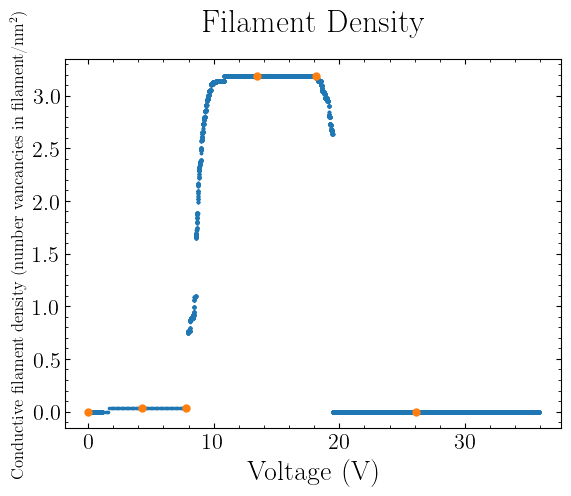

In [28]:

fig, axes = plt.subplots()
config_ax(axes)

# Configurar etiquetas y título
axes.set_xlabel(r"Voltage (\si{\V})")  # (\si{\nano\meter^{-1}})
axes.set_ylabel(r"Conductive filament density (number vancancies in filament/\si{\nano\meter^{2}})", fontsize=12)
axes.set_title(fr"Filament Density", pad=20)
    
axes.scatter(tiempo, densidad_filamento, s=2.5)
axes.scatter(representar[:, 0], representar[:, 1], s=25)

plt.show()
fig.savefig(save_path + '.svg', bbox_inches='tight')
plt.close(fig)

### Diferentes valores de resistencia

num_simulation 1  etiqueta R = 1.0 (\Omega) \quad \gamma = 8 \quad factor = 1.2
num_simulation 13  etiqueta R = 2.0 (\Omega) \quad \gamma = 8 \quad factor = 1.2
num_simulation 25  etiqueta R = 3.0 (\Omega) \quad \gamma = 8 \quad factor = 1.2


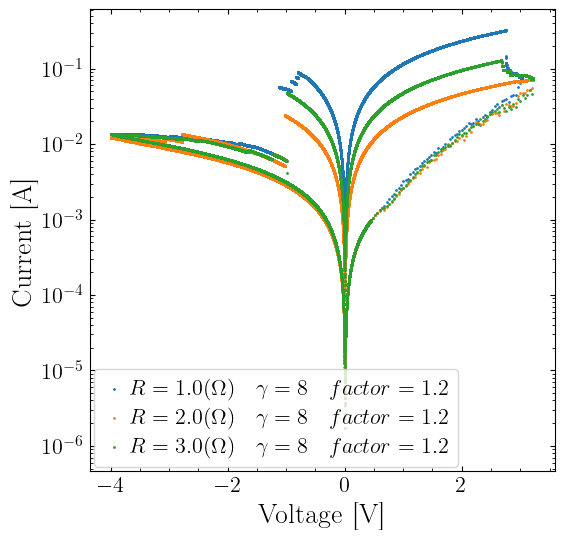

In [31]:
def obtein_data(num_simulation: int, 
                x_data: str,
                y_data: str,
                root_path: str = 'C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/') -> None:

    # Rutas datos
    set_simulation_path = os.path.join(root_path + 'Results/', f'simulation_{num_simulation}/set/')
    reset_simulation_path = os.path.join(root_path + 'Results/', f'simulation_{num_simulation}/reset/')

    # Rutas a los dataframes
    data_path_pp_set = set_simulation_path + f'resultados_pp_set_{num_simulation}.csv'
    data_path_sp_set = set_simulation_path + f'resultados_sp_set_{num_simulation}.csv'
    data_path_pp_reset = reset_simulation_path + f'resultados_pp_reset_{num_simulation}.csv'
    data_path_sp_reset = reset_simulation_path + f'resultados_sp_reset_{num_simulation}.csv'
    

    # Leo los data frames
    df_pset = pd.read_csv(data_path_pp_set, dtype=float)
    df_sset = pd.read_csv(data_path_sp_set, dtype=float)
    df_preset = pd.read_csv(data_path_pp_reset, dtype=float)
    df_sreset = pd.read_csv(data_path_sp_reset, dtype=float)

    data_y_ps = np.array(df_pset[y_data])
    data_y_ss = np.array(df_sset[y_data])
    data_y_pr = np.array(df_preset[y_data])
    data_y_sr = np.array(df_sreset[y_data])

    data_x_ps = np.array(df_pset[x_data])
    data_x_ss = np.array(df_sset[x_data])
    data_x_pr = np.array(df_preset[x_data])
    data_x_sr = np.array(df_sreset[x_data])

    # Uno en un solo array las intensidades y los voltajes de las curvas de SET
    data_x = np.concatenate((data_x_ps, data_x_ss, data_x_pr, data_x_sr))
    data_y = np.concatenate((data_y_ps, data_y_ss, data_y_pr, data_y_sr))
    
    return data_x, data_y

setup_plt(plt, latex=True, scaling=2)
fig, axes = plt.subplots(figsize=(6, 6))
config_ax(axes)

axes.set_xlabel('Voltage [V]')
axes.set_ylabel('Current [A]')
axes.set_yscale('log')

vector = np.array([1,13, 25])
etiqueta = ["R = 1.0 (\Omega) \quad \gamma = 8 \quad factor = 1.2", 
            "R = 2.0 (\Omega) \quad \gamma = 8 \quad factor = 1.2",
            "R = 3.0 (\Omega) \quad \gamma = 8 \quad factor = 1.2"]

for i in range(len(vector)):
    
    num_simulation = vector[i]
    print('num_simulation', num_simulation, " etiqueta", etiqueta[i])
    voltaje, intensidad = obtein_data(num_simulation, 'Voltaje [V]', 'Intensidad [A]')
    
    # Scatter de SET y RESET
    axes.scatter(voltaje, intensidad, s=1, marker='o', label=fr"${etiqueta[i]}$")
    # Leyenda ajustada
    axes.legend(
        labelspacing=0.3,
        handletextpad=0.2,
        handlelength=1.0,
        borderaxespad=0.2,
        loc='best',
    )
    
fig.savefig(f'resitencias.png', bbox_inches='tight')

# plt.close(fig)  # Cierra para liberar memoria